In [1]:
import os,sys
import torchvision
import argparse
import torch
import tqdm

In [2]:
sys.path.append("/home/jovyan/rt-detr/rt-detr")
from src.solver.utils import output_to_smiles

os.chdir('/home/jovyan/rt-detr/rt-detr')
os.getcwd()

ImportError: cannot import name 'datapoints' from 'torchvision' (/home/jovyan/bo2/miniconda/envs/detr/lib/python3.10/site-packages/torchvision/__init__.py)

In [ ]:

import src.misc.dist as dist 
from src.core import YAMLConfig 
from src.solver import TASKS
from src.data import get_coco_api_from_dataset



In [4]:
import rdkit

In [5]:
a1="CN(C)S(=O)(=O)NC(=O)C1C=CC2=C(C=1)N1CC3(CC3C3C=C(C=CC=3C1=C2C1CCCCC1)OC)C(=O)N1C2COCC1CCC2"
rdkit.Chem.MolFromSmiles(a1)

In [ ]:
#trained with /home/jovyan/rt-detr/data/real_processed/merge_with_chiral+charge_large/merged_file.csv
#57324 coco style processed

In [5]:
home="/home/jovyan/rt-detr"
pp="tools/output/rtdetr_r50vd_6x_coco_real_resample_charge_large/best_checkpoint.pth"
cc="tools/output/rtdetr_r50vd_6x_coco_real_resample_adapter_both/checkpoint0068.pth"
tt="./output/rtdetr_r50vd_6x_coco_real_resample_charge_large_adpter2/best_checkpoint.pth"
parser = argparse.ArgumentParser()
parser.add_argument('--config', '-c', type=str, default=f'{home}/rt-detr/configs/rtdetr/rtdetr_r50vd_6x_coco.yml')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/tools/output/rtdetr_r50vd_6x_coco_real_resample_charge_large/checkpoint0032.pth')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/tools/output/rtdetr_r50vd_6x_coco_real_resample/checkpoint0052.pth')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/{pp}')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/{cc}')
parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/{tt}')

parser.add_argument('--tuning', '-t', type=str,)# default='/home/jovyan/model_checkpoint/rtdetr_r50vd_2x_coco_objects365_from_paddle.pth')
parser.add_argument('--test-only',default=True,)
parser.add_argument('--amp', default=False,)

args, unknown = parser.parse_known_args()#in jupyter

In [6]:
args.config

'/home/jovyan/rt-detr/rt-detr/configs/rtdetr/rtdetr_r50vd_6x_coco.yml'

In [8]:
# import pprint
# import yaml

In [9]:
args.config

'/home/jovyan/rt-detr/rt-detr/configs/rtdetr/rtdetr_r50vd_6x_coco.yml'

In [7]:
cfg = YAMLConfig(
        args.config,
        resume=args.resume, 
        use_amp=args.amp,
        tuning=args.tuning
    )
args.gpu_device=0
cfg.device=torch.device('cuda', args.gpu_device)

In [10]:
_model=cfg.model

Load PResNet50 state_dict


In [13]:
# # cfg.yaml_cfg['val_dataloader']['dataset']['img_folder']='/home/jovyan/rt-detr/data/real_processed/merge_with_chiral_resample/images/val'
# # cfg.yaml_cfg['val_dataloader']['dataset']['ann_file']='/home/jovyan/rt-detr/data/real_processed/merge_with_chiral_resample/annotations/val.json'
# cfg.yaml_cfg['val_dataloader']['dataset']['img_folder']='/home/jovyan/rt-detr/rt-detr/data/chemical_molecule/images/val'
# cfg.yaml_cfg['val_dataloader']['dataset']['ann_file']='/home/jovyan/rt-detr/rt-detr/data/chemical_molecule/annotations/val.json'
# # ~/rt-detr/data/chemical_molecule/images/

In [19]:
print("when training use this as valdation dataset::",
    cfg.yaml_cfg['val_dataloader']['dataset']['img_folder'],"\n",
cfg.yaml_cfg['val_dataloader']['dataset']['ann_file'])

when training use this as valdation dataset:: /home/jovyan/rt-detr/data/real_processed/CLEF_with_charge/images/test 
 /home/jovyan/rt-detr/data/real_processed/CLEF_with_charge/annotations/test.json


In [15]:
print_usage(file=None)(type(cfg.val_dataloader))#note this val_dataloader is the training config used, not used for testing 
print(cfg.val_dataloader.dataset)

loading annotations into memory...
Done (t=0.35s)
creating index...
index created!


src.data.dataloader.DataLoader

In [20]:
base_ds = get_coco_api_from_dataset(cfg.val_dataloader.dataset)
print(base_ds.__dict__)

In [24]:
#data feeding
_val_dataloader=cfg._val_dataloader
samples_list=[]
targets_list=[]
for i, (samples, targets) in tqdm.tqdm(enumerate(_val_dataloader)):
    samples_list.append(samples)
    targets_list.append(targets)#box class annotation
    if i ==100:
        break
    # print(samples, targets)



2it [00:00,  5.63it/s]

86it [00:02, 29.33it/s]


In [26]:
samples.size()#TODO image need prepare in this size for model input

torch.Size([7, 3, 640, 640])

In [ ]:

# _model.training=False
_model.eval()#have to uset this
with torch.no_grad():
    print(_model.training)
    outputs=_model(samples)#等my给出新的weights path or model codes file

In [ ]:
#data prepareing 

In [ ]:
import json
import pandas as pd
from tqdm import tqdm



In [ ]:
with open('/home/jovyan/rt-detr/data/real_processed/merge_with_chiral_resample/annotations/val.json', 'r') as file:
    data = json.load(file)
image_id_to_name = {}

for image_data in data['images']:
    image_id = image_data['id']
    image_path = image_data['file_name']
    image_name = os.path.basename(image_path)
    image_id_to_name[image_id] = image_name

In [ ]:
res_smiles = []
smiles_data = pd.DataFrame({'file_name': [],
                        'SMILES':[]})

output_dict = {}
target_dict = {}
filtered_output_dict = {}

In [ ]:
samples_list=[]
targets_list=[]
for i, (samples, targets) in tqdm(enumerate(cfg.val_dataloader)):
    samples_list.append(samples)
    targets_list.append(targets)#box class annotation
    if i ==100:
        break
    # print(samples, targets)

100it [00:05, 18.40it/s]


In [ ]:
samples_list[0].size()#batch=12

torch.Size([10, 3, 640, 640])

In [ ]:
saved_statDict=torch.load(cfg.resume)

In [ ]:
#model loading and prediction
# import src
# # solver = TASKS[cfg.yaml_cfg['task']](cfg)#DetSolver
# solver=src.solver.det_solver.DetSolver(cfg)
# solver.eval()#have to as need load trainned weights
# model=solver.ema.module.to('cpu') 
# model.eval()#have to use
# outputs = model(samples)

saved_statDict=torch.load(cfg.resume)
loaded_state_dict=saved_statDict['model']
#comaparing with pretrained_model
_model=cfg._model.to('cpu')
current_model_dict=_model.state_dict()

In [ ]:
class bcolors:
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKCYAN = '\033[96m'
    OKGREEN = '\033[92m'
    WARNING = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'

#NOTE make sure current_model_dict contating all the loaded_state_dict
key_ori=loaded_state_dict.keys()
key_cur=current_model_dict.keys()
diff_cur=[k for k in key_cur  if k not in key_ori]
diff_ori=[k for k in key_ori if k not in key_cur]#loaded is the original as pretrained
#hehre we only considering new model >= pretrained, not the other case here
same_=[k for k in key_cur if k in key_ori]
# assert len(diff_ori)==0, 
print(f'make sure loaded pretrained model keys: {len(key_ori)} are all included in current build model keys: {len(key_cur)}\n In futhre we considering only part intersection!!')
new_state_dict=dict()
i=0;j=0
for k in same_:
    if loaded_state_dict[k].size()==current_model_dict[k].size():
        new_state_dict[k]=loaded_state_dict[k]
        # print(f'current{k},{current_model_dict[k].size()},ori{loaded_state_dict[k].size()}')
        i+=1
    else:
        new_state_dict[k]=current_model_dict[k] #confg such image_size diff lead
        j+=1
_model.load_state_dict(new_state_dict, strict=False)
print(f'{bcolors.WARNING}have partly load the match paramters>>number of:{len(new_state_dict.keys())}@finalLoad, all:{len(current_model_dict.keys())}@buildModel, {len(loaded_state_dict.keys())}@pretrained. {bcolors.ENDC}')
print(f' {bcolors.WARNING} loaded keys {i}, skip mismatch size keys {j} (same nnName but diff dimensions)')


make sure loaded pretrained model keys: 736 are all included in current build model keys: 736
 In futhre we considering only part intersection!!
have partly load the match paramters>>number of:736@finalLoad, all:736@buildModel, 736@pretrained. 
  loaded keys 736, skip mismatch size keys 0 (same nnName but diff dimensions)


In [ ]:
#data feeding
_val_dataloader=cfg._val_dataloader
samples_list=[]
targets_list=[]
for i, (samples, targets) in tqdm(enumerate(_val_dataloader)):
    samples_list.append(samples)
    targets_list.append(targets)#box class annotation
    if i ==100:
        break
    # print(samples, targets)


# _model.training=False
_model.eval()#have to uset this
with torch.no_grad():
    print(_model.training)
    outputs=_model(samples)#等my给出新的weights path or model codes file

100it [00:03, 30.82it/s]


In [ ]:
# _model.training=False
_model.eval()#have to uset this
with torch.no_grad():
    print(_model.training)
    outputs=_model(samples)#等my给出新的weights path or model codes file

False


In [ ]:
orig_target_sizes = torch.stack([t["orig_size"] for t in targets], dim=0)        
orig_target_sizes.size()

torch.Size([10, 2])

In [ ]:
postprocessors=cfg.postprocessor

In [ ]:
results = postprocessors(outputs, orig_target_sizes)


In [ ]:
output_dict={}
for t, o in zip(targets, results):
    output_dict[t['image_id'].item()] = o


In [ ]:
list(o.keys()),o['scores'].size(),o['boxes'].size(),

(['labels', 'boxes', 'scores'], torch.Size([300]), torch.Size([300, 4]))

In [ ]:
filtered_output_dict = {}

for key, value in output_dict.items():
    selected_indices = value['scores'] > 0.5
    filtered_output_dict[key] = {
        'labels': value['labels'][selected_indices],
        'boxes': value['boxes'][selected_indices],
        'scores': value['scores'][selected_indices]
    }

In [ ]:
bond_labels = [13,14,15,16,17]
idx_to_labels = {0:'other',1:'C',2:'O',3:'N',4:'Cl',5:'Br',6:'S',7:'F',8:'B',
                9:'I',10:'P',11:'*',12:'Si',13:'NONE',14:'BEGINWEDGE',15:'BEGINDASH',
                16:'=',17:'#',18:'-4',19:'-2',20:'-1',21:'1',22:'+2',} #NONE is single ?



In [ ]:
for i,(key,value) in enumerate(filtered_output_dict.items()):
    result = []
    res_smiles.append(output_to_smiles(value,idx_to_labels,bond_labels,result))
    new_row = {'file_name':image_id_to_name[key],
                'SMILES':res_smiles[i]}
    smiles_data = smiles_data._append(new_row, ignore_index=True)

捕获到 AtomValenceException 异常@@Explicit valence for atom # 12 C greater than permitted


In [ ]:
smiles_data

,file_name,SMILES
0,16109.png,C.C.C=C.C=C=C=C=C=O.C=C=C=N.C=N.C=N.C=N.C=N.C=...
1,6779.png,C.C=C.C=C=C=N.C=C=C=[IH].C=C=N.C=N.C=N.Cl.N.N....
2,9267.png,C.C=C.C=C.C=C.C=C=C=C=C=C.C=C=C=N.C=C=P.Cl.N=C...
3,56680.png,C=C.C=C.C=C.C=C=C=C.C=C=C=N.C=C=C=N.C=C=N.C=C=...
4,21100.png,C=C.C=C.C=C=C.C=C=C.C=C=O.O.O
5,47957.png,C=C=C=C=C=C=O.Cl.O
6,39052.png,C.C.C=C.C=C.C=C=C.C=C=C=C.C=C=C=N.C=C=C=N.C=C=...
7,35252.png,None
8,27784.png,C.C.C.C#C.C#C.C=C.C=C.C=C=C.C=C=C.C=C=N.C=C=O....
9,30799.png,C.C=C.C=C.C=C=C.C=C=C.C=C=C=C=C.C=N.N=N.O


In [ ]:
import torch.nn.functional as F 
import torchvision

In [ ]:
#prediction postprocesss 
logits, boxes = outputs['pred_logits'], outputs['pred_boxes']
scores = F.sigmoid(logits)
bbox_pred = torchvision.ops.box_convert(boxes, in_fmt='cxcywh', out_fmt='xyxy')



# _postprocess=cfg.postprocessor
# orig_target_sizes=torch.stack([[640,640] for i  in range(outputs['pred_logits'].size(0))],dim=0)

In [ ]:
scores = F.softmax(logits)[:, :, :-1]
scores, labels = scores.max(dim=-1)
boxes = bbox_pred

/tmp/ipykernel_629435/1994865172.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  scores = F.softmax(logits)[:, :, :-1]


scores.shape[1]

In [ ]:
scores.shape,labels.shape

(torch.Size([10, 300]), torch.Size([10, 300]))

In [ ]:
cfg.postprocessor.num_top_queries

300

In [ ]:
results = cfg.postprocessor(outputs, orig_target_sizes)


In [ ]:
bond_labels = [16,17,18,19,20,21,22]
idx_to_labels = {0:'other',1: 'C0', 2: 'O0', 3: 'N0', 4: 'Cl0', 5: 'C-1', 
                6: 'Br0', 7: 'N1', 8: 'O-1', 9: 'S0', 10: 'F0', 11: 'B0', 
                12: 'I0', 13: 'P0', 14: '*0', 15: 'Si0', 16: 'NONE', 
                17: 'ENDUPRIGHT', 18: 'BEGINWEDGE', 19: 'BEGINDASH', 
                20: 'ENDDOWNRIGHT', 21: '=', 22: '#'}

In [ ]:
#output_to_smiles process

In [ ]:
filtered_output_dict.keys()

dict_keys([1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009])

In [ ]:
output_dict.keys()

dict_keys([1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009])

In [ ]:
for i,(key,value) in enumerate(filtered_output_dict.items()):
    result = []
    res_smiles.append(output_to_smiles(value,idx_to_labels,bond_labels,result))

Error||('N00', 'N0')@@Post-condition Violation
	Element 'N0' not found
	Violation occurred on line 93 in file Code/GraphMol/PeriodicTable.h
	Failed Expression: anum > -1
	RDKIT: 2024.03.5
	BOOST: 1_85

Error||('C00', 'C0')@@Post-condition Violation
	Element 'C0' not found
	Violation occurred on line 93 in file Code/GraphMol/PeriodicTable.h
	Failed Expression: anum > -1
	RDKIT: 2024.03.5
	BOOST: 1_85

Error||('C00', 'C0')@@Post-condition Violation
	Element 'C0' not found
	Violation occurred on line 93 in file Code/GraphMol/PeriodicTable.h
	Failed Expression: anum > -1
	RDKIT: 2024.03.5
	BOOST: 1_85

Error||('O00', 'O0')@@Post-condition Violation
	Element 'O0' not found
	Violation occurred on line 93 in file Code/GraphMol/PeriodicTable.h
	Failed Expression: anum > -1
	RDKIT: 2024.03.5
	BOOST: 1_85

Error||('C00', 'C0')@@Post-condition Violation
	Element 'C0' not found
	Violation occurred on line 93 in file Code/GraphMol/PeriodicTable.h
	Failed Expression: anum > -1
	RDKIT: 2024.03.5
	BOO

In [ ]:
value

{'labels': tensor([21, 16, 21, 16, 16, 21, 16, 16, 21,  1, 16,  1, 21, 16, 16, 21, 16,  1,
          1,  1,  1, 16, 16, 16, 16,  1,  1, 21,  1, 16,  3, 16,  3,  1, 16,  1,
          1,  1,  2,  3,  1,  1,  1,  1]),
 'boxes': tensor([[124.8740,  88.8095, 165.6364, 127.6580],
         [227.8759, 138.8949, 254.8563, 178.7054],
         [ 48.7998, 159.0508,  88.7187, 197.7910],
         [108.8028, 148.7190, 144.7909, 181.7698],
         [227.7698, 168.7394, 254.8686, 208.7692],
         [183.8740,  81.8320, 228.2846, 114.7749],
         [ 75.7282, 161.0061, 118.8145, 181.7624],
         [ 68.8323, 127.8649,  85.7546, 170.9181],
         [225.8806, 104.8063, 254.2052, 151.7655],
         [107.8066, 170.8310, 119.7743, 182.7906],
         [126.8853, 114.8047, 144.7770, 158.6283],
         [226.8544, 137.8635, 238.8204, 149.8255],
         [132.7729, 146.7790, 180.7733, 171.7749],
         [244.8807, 167.7790, 289.7956, 178.6886],
         [152.6671,  90.8391, 195.8526, 111.8012],
         [ 

In [ ]:
orig_target_sizes = torch.stack([t["orig_size"] for t in targets], dim=0)

results = cfg.postprocessor(output1, orig_target_sizes)
res = {target['image_id'].item(): output for target, output in zip(targets, results)}

orig_target_sizes.size()

NameError: name 'output1' is not defined

In [ ]:
for target, output in zip(targets, results):
    output_dict[target['image_id'].item()] = output

In [ ]:
for key, value in output_dict.items():
    selected_indices = value['scores'] > 0.5#manualy setting
    filtered_output_dict[key] = {
        'labels': value['labels'][selected_indices],
        'boxes': value['boxes'][selected_indices],
        'scores': value['scores'][selected_indices]
    }

In [ ]:
filtered_output_dict.keys()

dict_keys([1200, 1201, 1202, 1203, 1204, 1205, 1206, 1207, 1208, 1209, 1210, 1211])

In [ ]:
bond_labels = [16,17,18,19,20,21,22]
idx_to_labels = {0:'other',1: 'C0', 2: 'O0', 3: 'N0', 4: 'Cl0', 5: 'C-1', 
                6: 'Br0', 7: 'N1', 8: 'O-1', 9: 'S0', 10: 'F0', 11: 'B0', 
                12: 'I0', 13: 'P0', 14: '*0', 15: 'Si0', 16: 'NONE', 
                17: 'ENDUPRIGHT', 18: 'BEGINWEDGE', 19: 'BEGINDASH', 
                20: 'ENDDOWNRIGHT', 21: '=', 22: '#'}

In [ ]:
filtered_output_dict

{1200: {'labels': tensor([], dtype=torch.int64),
  'boxes': tensor([], size=(0, 4)),
  'scores': tensor([])},
 1201: {'labels': tensor([], dtype=torch.int64),
  'boxes': tensor([], size=(0, 4)),
  'scores': tensor([])},
 1202: {'labels': tensor([], dtype=torch.int64),
  'boxes': tensor([], size=(0, 4)),
  'scores': tensor([])},
 1203: {'labels': tensor([], dtype=torch.int64),
  'boxes': tensor([], size=(0, 4)),
  'scores': tensor([])},
 1204: {'labels': tensor([], dtype=torch.int64),
  'boxes': tensor([], size=(0, 4)),
  'scores': tensor([])},
 1205: {'labels': tensor([], dtype=torch.int64),
  'boxes': tensor([], size=(0, 4)),
  'scores': tensor([])},
 1206: {'labels': tensor([], dtype=torch.int64),
  'boxes': tensor([], size=(0, 4)),
  'scores': tensor([])},
 1207: {'labels': tensor([], dtype=torch.int64),
  'boxes': tensor([], size=(0, 4)),
  'scores': tensor([])},
 1208: {'labels': tensor([], dtype=torch.int64),
  'boxes': tensor([], size=(0, 4)),
  'scores': tensor([])},
 1209: {'l

In [ ]:
output=filtered_output_dict[1200]
x_center = (output["boxes"][:, 0] + output["boxes"][:, 2]) / 2
y_center = (output["boxes"][:, 1] + output["boxes"][:, 3]) / 2
center_coords = torch.stack((x_center, y_center), dim=1)
output = {'bbox':         output["boxes"].to("cpu").numpy(),
            'bbox_centers': center_coords.to("cpu").numpy(),
            'scores':       output["scores"].to("cpu").numpy(),
            'pred_classes': output["labels"].to("cpu").numpy()}

KeyError: 1200

In [ ]:
output

NameError: name 'output' is not defined

In [ ]:
atoms_mask = np.array([True if ins not in bond_labels else False for ins in output['pred_classes']])
# get atom list
atoms_list = [idx_to_labels[a] for a in output['pred_classes'][atoms_mask]]
atoms_list = pd.DataFrame({'atom': atoms_list,
                    'x':    output['bbox_centers'][atoms_mask, 0],
                    'y':    output['bbox_centers'][atoms_mask, 1]})


IndexError: arrays used as indices must be of integer (or boolean) type

In [ ]:
#below are poster rebulit related codes

In [ ]:
from rdkit import Chem
from rdkit.Chem.Draw import rdDepictor
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import rdMolEnumerator
import rdkit
print(rdkit.__version__)

2024.03.3


In [ ]:
smi = 'CCC(COC(=O)[C@@H](NP(=O)(Oc1ccccc1)OC[C@H]1O[C@@]([C@@H]([C@@H]1O)O)(C#N)c1ccc2n1ncnc2N)C)CC' # Remdesivir
mol = Chem.MolFromSmiles(smi)
if  not mol.GetNumConformers():
    rdDepictor.Compute2DCoords(mol)
conf = mol.GetConformer()
Chem.WedgeMolBonds(mol,conf)
print ('Printing bond directions....')
for bond in mol.GetBonds():
    if bond.GetBondDir() != Chem.BondDir.NONE: print (bond.GetIdx(), bond.GetBondDir())

Printing bond directions....
19 BEGINDASH
24 BEGINWEDGE
25 BEGINWEDGE
26 BEGINWEDGE
38 BEGINWEDGE


In [ ]:
chiral_centers = Chem.FindMolChiralCenters(mol, includeUnassigned=True, includeCIP=False, useLegacyImplementation=False)
chiral_centers

[(7, 'Tet_CW'),
 (9, '?'),
 (20, 'Tet_CW'),
 (22, 'Tet_CW'),
 (23, 'Tet_CW'),
 (24, 'Tet_CCW')]

In [ ]:
rdkitbond_type_dict = {
            rdkit.Chem.rdchem.BondType.SINGLE:1,
            rdkit.Chem.rdchem.BondType.DOUBLE:2,
            rdkit.Chem.rdchem.BondType.TRIPLE:3,
            rdkit.Chem.rdchem.BondType.AROMATIC:4,
            }
rdkitbond_dir_dict = {
            rdkit.Chem.rdchem.BondDir.BEGINWEDGE:5,
            rdkit.Chem.rdchem.BondDir.BEGINDASH:6,
            rdkit.Chem.rdchem.BondDir.UNKNOWN:7,
            rdkit.Chem.rdchem.BondDir.ENDUPRIGHT:8,
            rdkit.Chem.rdchem.BondDir.ENDDOWNRIGHT:9,
}

i2rdkitBond={
   1:rdkit.Chem.rdchem.BondType.SINGLE,
   2:rdkit.Chem.rdchem.BondType.DOUBLE,
   3:rdkit.Chem.rdchem.BondType.TRIPLE,
   4:rdkit.Chem.rdchem.BondType.AROMATIC,
   5:rdkit.Chem.rdchem.BondDir.BEGINWEDGE,
   6:rdkit.Chem.rdchem.BondDir.BEGINDASH,
   7:rdkit.Chem.rdchem.BondDir.UNKNOWN,
   8:rdkit.Chem.rdchem.BondDir.ENDUPRIGHT,
   9:rdkit.Chem.rdchem.BondDir.ENDDOWNRIGHT,
   }

In [ ]:
# 原smiles   
ori="O=C([C@@H]1[C@H](/C=C/C2=CC=CC=C2)C[C@@H]1/C=C/C3=CC=CC=C3)NC4=C5C(C=CC=N5)=CC=C4"

# 重构的smiles  
# O=C(Nc1cccc2cccnc12)[C@H]1C(C=Cc2ccccc2)C[C@H]1C=Cc1ccccc1

In [ ]:
Chem.MolToSmiles(me)

'O=C(Nc1cccc2cccnc12)[C@@H]1[C@H](C=Cc2ccccc2)C[C@@H]1C=Cc1ccccc1'

0
O=C(Nc1cccc2cccnc12)[C@@H]1[C@H](/C=C/c2ccccc2)C[C@@H]1/C=C/c1ccccc1


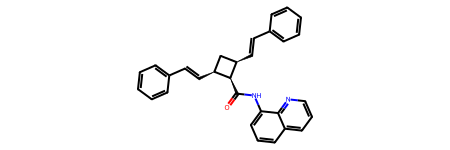

In [ ]:

# m = Chem.MolFromSmiles('CC123.F2.Cl1.Br3')
m = Chem.MolFromSmiles(ori)
Chem.rdDepictor.Compute2DCoords(m)
print(m.GetNumConformers())
Chem.rdmolops.WedgeMolBonds(m,m.GetConformer(0))
print(Chem.MolToSmiles(m))

m

In [ ]:


symbols=[]
charges=[]
coords=[]
atoms = [atom for atom in m.GetAtoms()]#TODO get atom net charge for using
for i, atom in enumerate(atoms):
    positions = m.GetConformer().GetAtomPosition(i)
    symbols.append(atom.GetSymbol())
    charges.append(atom.GetFormalCharge())       
    print(atom.GetSymbol(), positions.x, positions.y, positions.z)
    coords.append([positions.x, positions.y,0])

O -1.2383213655152443 -2.3690235877563803 0.0
C -0.3504647905856173 -1.1600113039667441 0.0
C -0.9535718543700694 0.2134011867341729 0.0
C -0.4088836634126392 1.6110115668585918 0.0
C 0.9645288272882774 2.2141186306430436 0.0
C 1.1289290341995561 3.705082269357126 0.0
C 2.502341524900472 4.308189333141579 0.0
C 3.7113538086901112 3.420332758211952 0.0
C 5.084766299391028 4.023439821996406 0.0
C 5.249166506302307 5.514403460710486 0.0
C 4.040154222512671 6.402260035640111 0.0
C 2.6667417318117534 5.7991529718556585 0.0
C -1.8064940435370576 2.1556997578160217 0.0
C -2.3511822344944884 0.7580893776916037 0.0
C -3.724594725195407 0.15498231390715045 0.0
C -4.9336070089850415 1.0428388888367799 0.0
C -6.3070194996859605 0.439731825052327 0.0
C -7.516031783475596 1.3275883999819555 0.0
C -8.889444274176514 0.7244813361975044 0.0
C -9.053844481087795 -0.7664823025165748 0.0
C -7.844832197298158 -1.6543388774462024 0.0
C -6.471419706597242 -1.0512318136617513 0.0
N 1.1404988481284621 -1.32441

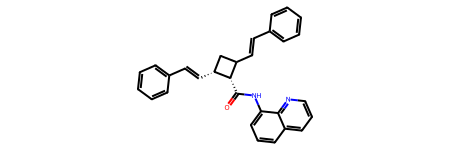

In [ ]:
Chem.MolFromSmiles("O=C(Nc1cccc2cccnc12)[C@H]1C(C=Cc2ccccc2)C[C@H]1C=Cc1ccccc1")

In [ ]:
bonds_list=[]
for jj,bond in enumerate(m.GetBonds()):
    s = bond.GetBeginAtomIdx()#rdkit not random atom order now
    t = bond.GetEndAtomIdx()
    if s in [2,3,13] or t in [2,3,13]:
        print(s,t,bond.GetBondDir())
    #not considering double bond dir
    if  bond.GetBondDir() in [rdkit.Chem.rdchem.BondDir.BEGINWEDGE,
                            rdkit.Chem.rdchem.BondDir.BEGINDASH,
                            rdkit.Chem.rdchem.BondDir.UNKNOWN,
                            rdkit.Chem.rdchem.BondDir.ENDUPRIGHT,
                            rdkit.Chem.rdchem.BondDir.ENDDOWNRIGHT,]:#NOTE indigo now no wavy bond only rdkit
        bond_type=rdkitbond_dir_dict[bond.GetBondDir()]
    else:
        bond_type=rdkitbond_type_dict[bond.GetBondType()]
        
    # print(bond.GetBondDir(),bond_type,[s,t])
    bonds_list.append((bond_type,s,t))

2 1 BEGINWEDGE
2 3 NONE
3 4 BEGINWEDGE
3 12 NONE
12 13 NONE
13 14 BEGINWEDGE
13 2 NONE


In [ ]:
[b for b in bonds_list if b[0]>=7]

[(8, 5, 6), (8, 15, 16)]

In [ ]:
# me = Chem.EditableMol(Chem.Mol())
me = Chem.RWMol()#read and write, better than the above

In [ ]:

for a,c in zip(symbols,charges):
    # print(a,c)
    if a in  ["R",'*']:     
        new_atom = Chem.Atom("*")
        new_atom.SetProp("atomLabel", "abb") 
        # mol.AddAtom(new_atom)
        me.AddAtom(new_atom)
    atom = Chem.Atom(a)#TODO when Rgroup rdkit not reconized
    atom.SetFormalCharge(c)
    me.AddAtom(atom)

for bond_type,s,t in bonds_list:
    if bond_type<=4:
        me.AddBond(s, t, i2rdkitBond[bond_type])
    else:
        me.AddBond(s, t, rdkit.Chem.rdchem.BondType.SINGLE)

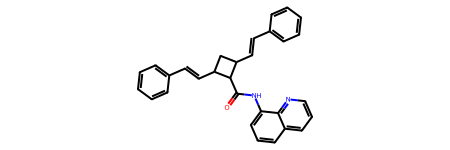

In [ ]:
mol_tmp = me.GetMol()
mol_tmp

In [ ]:
chiral_centers = Chem.FindMolChiralCenters(mol_tmp, includeUnassigned=True, includeCIP=False, useLegacyImplementation=False)
chiral_center_ids = [idx for idx, _ in chiral_centers] 
print(chiral_centers,chiral_center_ids)
chiral_center_ids_neibor={}
for chi in chiral_center_ids:
    ats=mol_tmp.GetAtomWithIdx(chi).GetNeighbors()
    chiral_center_ids_neibor[chi]=[at.GetIdx() for at in ats]
    print(chiral_center_ids_neibor)


[(2, '?'), (3, '?'), (13, '?')] [2, 3, 13]
{2: [1, 3, 13]}
{2: [1, 3, 13], 3: [2, 4, 12]}
{2: [1, 3, 13], 3: [2, 4, 12], 13: [12, 14, 2]}


In [ ]:
conf = Chem.Conformer(me.GetNumAtoms())
conf.Set3D(False)
for i, (x, y,z) in enumerate(coords):
    conf.SetAtomPosition(i, (x, y, z))
me.AddConformer(conf)

0

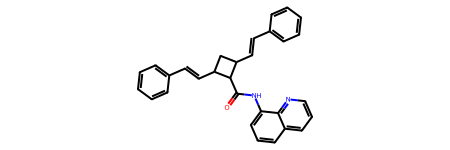

In [ ]:
Chem.MolToSmiles(me)
me

In [ ]:
# Create conformer from 2D coordinate
me.RemoveAllConformers()
conf = Chem.Conformer(me.GetNumAtoms())
conf.Set3D(True)
for i, (x, y,z) in enumerate(coords):
    conf.SetAtomPosition(i, (x, y, z))
me.AddConformer(conf)
Chem.SanitizeMol(me)
Chem.AssignStereochemistryFrom3D(me)
# NOTE: seems that only AssignStereochemistryFrom3D can handle double bond E/Z
# So we do this first, remove the conformer and add back the 2D conformer for chiral correction


In [ ]:
ez_smi=Chem.MolToSmiles(me)#no E/Z
ez_smi

'O=C(Nc1cccc2cccnc12)C1C(/C=C/c2ccccc2)CC1/C=C/c1ccccc1'

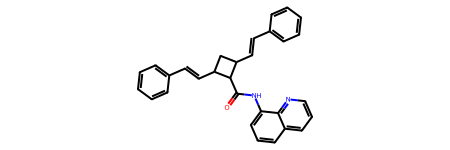

In [ ]:
me

In [ ]:
#add bond direaction 
for i in chiral_center_ids:
    for j in chiral_center_ids_neibor[i]:
        # print(i,j)
        # if edges[i][j] == 5:
        if (5,i,j)    or (5,j,i)  in bonds_list  :
            # me.RemoveBond(i, j)
            # me.AddBond(i, j, Chem.BondType.SINGLE)
            # me.GetBondBetweenAtoms(i, j).SetBondDir(Chem.BondDir.BEGINDASH)
            me.GetBondBetweenAtoms(i, j).SetBondDir(Chem.BondDir.BEGINWEDGE)
            # print([i,j],5)
        elif (6,i,j)   or (6,j,i) in bonds_list  :
            # me.RemoveBond(i, j)
            # me.AddBond(i, j, Chem.BondType.SINGLE)
            me.GetBondBetweenAtoms(i, j).SetBondDir(Chem.BondDir.BEGINWEDGE)
            # print([i,j],6)

        # elif (8,i,j)    in bonds_list:
        #     me.GetBondBetweenAtoms(i, j).SetBondDir(Chem.BondDir.ENDUPRIGHT)
        # elif (9,i,j)    in bonds_list:
        #     me.GetBondBetweenAtoms(i, j).SetBondDir(Chem.BondDir.ENDDOWNRIGHT)


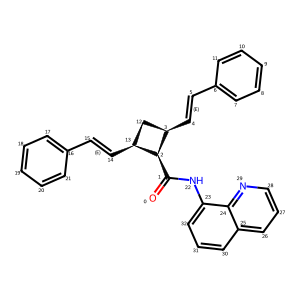

In [ ]:
opts = Draw.MolDrawOptions()
opts.addAtomIndices = True
opts.addStereoAnnotation = True
Draw.MolToImage(me, options=opts)

In [ ]:
# magic
Chem.SanitizeMol(me)
Chem.DetectBondStereochemistry(me)
Chem.AssignChiralTypesFromBondDirs(me)
Chem.AssignStereochemistry(me)
Chem.MolToSmiles(me)

'O=C(Nc1cccc2cccnc12)[C@@H]1[C@H](/C=C/c2ccccc2)C[C@@H]1/C=C/c1ccccc1'

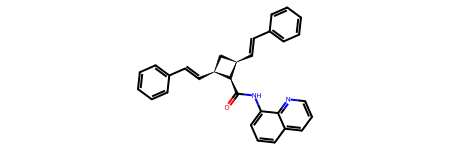

In [ ]:
me

In [ ]:
conf = Chem.Conformer(me.GetNumAtoms())
conf.Set3D(False)
for i, (x, y,z) in enumerate(coords):
    conf.SetAtomPosition(i, (x, y, z))
me.AddConformer(conf)

0

In [ ]:
# magic
Chem.SanitizeMol(me)
Chem.DetectBondStereochemistry(me)
Chem.AssignChiralTypesFromBondDirs(me)
Chem.AssignStereochemistry(me)

Atoms:
	0 8 O chg: 0  deg: 1 exp: 2 imp: 0 hyb: SP2
	1 6 C chg: 0  deg: 3 exp: 4 imp: 0 hyb: SP2
	2 6 C chg: 0  deg: 3 exp: 4 imp: 0 hyb: SP3 chi: CCW nbrs:[1 3 13]
	3 6 C chg: 0  deg: 3 exp: 4 imp: 0 hyb: SP3 chi: CCW nbrs:[2 4 12]
	4 6 C chg: 0  deg: 2 exp: 3 imp: 1 hyb: SP2
	5 6 C chg: 0  deg: 2 exp: 3 imp: 1 hyb: SP2
	6 6 C chg: 0  deg: 3 exp: 4 imp: 0 hyb: SP2 arom?: 1
	7 6 C chg: 0  deg: 2 exp: 3 imp: 1 hyb: SP2 arom?: 1
	8 6 C chg: 0  deg: 2 exp: 3 imp: 1 hyb: SP2 arom?: 1
	9 6 C chg: 0  deg: 2 exp: 3 imp: 1 hyb: SP2 arom?: 1
	10 6 C chg: 0  deg: 2 exp: 3 imp: 1 hyb: SP2 arom?: 1
	11 6 C chg: 0  deg: 2 exp: 3 imp: 1 hyb: SP2 arom?: 1
	12 6 C chg: 0  deg: 2 exp: 2 imp: 2 hyb: SP3
	13 6 C chg: 0  deg: 3 exp: 4 imp: 0 hyb: SP3 chi: CCW nbrs:[12 14 2]
	14 6 C chg: 0  deg: 2 exp: 3 imp: 1 hyb: SP2
	15 6 C chg: 0  deg: 2 exp: 3 imp: 1 hyb: SP2
	16 6 C chg: 0  deg: 3 exp: 4 imp: 0 hyb: SP2 arom?: 1
	17 6 C chg: 0  deg: 2 exp: 3 imp: 1 hyb: SP2 arom?: 1
	18 6 C chg: 0  deg: 2 exp: 3 imp

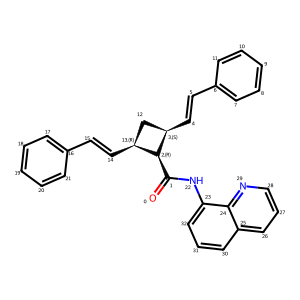

In [ ]:
me.Debug()
opts = Draw.MolDrawOptions()
opts.addAtomIndices = True
opts.addStereoAnnotation = True
Draw.MolToImage(me, options=opts)

In [ ]:
Chem.MolToSmiles(me)

'O=C(Nc1cccc2cccnc12)[C@@H]1[C@H](C=Cc2ccccc2)C[C@@H]1C=Cc1ccccc1'

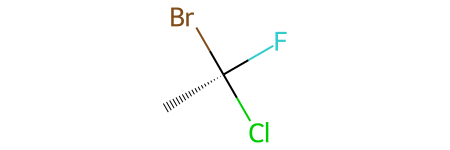

In [ ]:
i=1
j=0
me.RemoveBond(i, j)
me.AddBond(i, j, Chem.BondType.SINGLE)
me2=me.GetMol()
# me2.GetBondBetweenAtoms(i, j).SetBondDir(Chem.BondDir.BEGINWEDGE)
me2.GetBondBetweenAtoms(i, j).SetBondDir(Chem.BondDir.BEGINDASH)

me2

In [ ]:
# Chem.SanitizeMol(me2)
# AssignAtomChiralTagsFromStructure
Chem.AssignChiralTypesFromBondDirs(me2,replaceExistingTags=True)#have to get the 2D coords before
Chem.AssignStereochemistry(me2, force=True)
Chem.MolToSmiles(me2)#'C[C@@](F)(Cl)Br'


'C[C@](F)(Cl)Br'

In [ ]:
Chem.MolToMolBlock(me2)

'\n     RDKit          2D\n\n  5  4  0  0  0  0  0  0  0  0999 V2000\n   -1.2990   -0.7500    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.0000   -0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    1.2990    0.7500    0.0000 F   0  0  0  0  0  0  0  0  0  0  0  0\n    0.7500   -1.2990    0.0000 Cl  0  0  0  0  0  0  0  0  0  0  0  0\n   -0.7500    1.2990    0.0000 Br  0  0  0  0  0  0  0  0  0  0  0  0\n  4  2  1  0\n  3  2  1  0\n  5  2  1  0\n  2  1  1  6\nM  END\n'

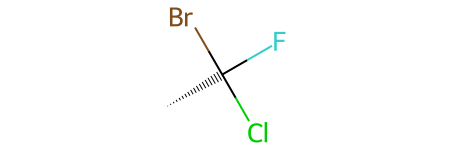

In [ ]:
m.GetBondBetweenAtoms(1, 0).SetBondDir(Chem.BondDir.BEGINDASH)
m

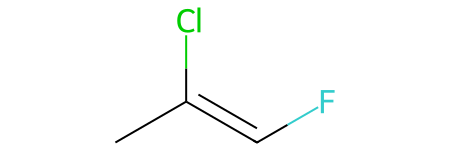

In [ ]:
mol = Chem.MolFromSmiles('CC(Cl)=CF')
mol

In [ ]:
import numpy as np
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from PIL import Image, ImageDraw


rdkitbond_type_dict = {
            rdkit.Chem.rdchem.BondType.SINGLE:1,
            rdkit.Chem.rdchem.BondType.DOUBLE:2,
            rdkit.Chem.rdchem.BondType.TRIPLE:3,
            rdkit.Chem.rdchem.BondType.AROMATIC:4,
            }
rdkitbond_dir_dict = {
            rdkit.Chem.rdchem.BondDir.BEGINWEDGE:5,
            rdkit.Chem.rdchem.BondDir.BEGINDASH:6,
            rdkit.Chem.rdchem.BondDir.UNKNOWN:7,
            rdkit.Chem.rdchem.BondDir.ENDUPRIGHT:8,
            rdkit.Chem.rdchem.BondDir.ENDDOWNRIGHT:9,
}

i2rdkitBond={
   1:rdkit.Chem.rdchem.BondType.SINGLE,
   2:rdkit.Chem.rdchem.BondType.DOUBLE,
   3:rdkit.Chem.rdchem.BondType.TRIPLE,
   4:rdkit.Chem.rdchem.BondType.AROMATIC,
   5:rdkit.Chem.rdchem.BondDir.BEGINWEDGE,
   6:rdkit.Chem.rdchem.BondDir.BEGINDASH,
   7:rdkit.Chem.rdchem.BondDir.UNKNOWN,
   8:rdkit.Chem.rdchem.BondDir.ENDUPRIGHT,
   9:rdkit.Chem.rdchem.BondDir.ENDDOWNRIGHT,
   }

# 原smiles   
ori="O=C([C@@H]1[C@H](/C=C/C2=CC=CC=C2)C[C@@H]1/C=C/C3=CC=CC=C3)NC4=C5C(C=CC=N5)=CC=C4"
# 重构的smiles  
# O=C(Nc1cccc2cccnc12)[C@H]1C(C=Cc2ccccc2)C[C@H]1C=Cc1ccccc1
# m = Chem.MolFromSmiles('CC123.F2.Cl1.Br3')
m = Chem.MolFromSmiles(ori)
orican=Chem.MolToSmiles(m)
Chem.rdDepictor.Compute2DCoords(m)
print(m.GetNumConformers())
Chem.rdmolops.WedgeMolBonds(m,m.GetConformer(0))
print(Chem.MolToSmiles(m))


#atom bonds charge corrds
symbols=[]
charges=[]
coords=[]
atoms = [atom for atom in m.GetAtoms()]#TODO get atom net charge for using
for i, atom in enumerate(atoms):
    positions = m.GetConformer().GetAtomPosition(i)
    symbols.append(atom.GetSymbol())
    charges.append(atom.GetFormalCharge())       
    print(atom.GetSymbol(), positions.x, positions.y, positions.z)
    coords.append([positions.x, positions.y,0])

bonds_list=[]
for jj,bond in enumerate(m.GetBonds()):
    s = bond.GetBeginAtomIdx()#rdkit not random atom order now
    t = bond.GetEndAtomIdx()
    if s in [2,3,13] or t in [2,3,13]:
        print(s,t,bond.GetBondDir())
    #not considering double bond dir
    if  bond.GetBondDir() in [rdkit.Chem.rdchem.BondDir.BEGINWEDGE,
                            rdkit.Chem.rdchem.BondDir.BEGINDASH,
                            rdkit.Chem.rdchem.BondDir.UNKNOWN,
                            rdkit.Chem.rdchem.BondDir.ENDUPRIGHT,
                            rdkit.Chem.rdchem.BondDir.ENDDOWNRIGHT,]:#NOTE indigo now no wavy bond only rdkit
        bond_type=rdkitbond_dir_dict[bond.GetBondDir()]
    else:
        bond_type=rdkitbond_type_dict[bond.GetBondType()]
        
    # print(bond.GetBondDir(),bond_type,[s,t])
    bonds_list.append((bond_type,s,t))

# me = Chem.EditableMol(Chem.Mol())
me = Chem.RWMol()#read and write, better than the above

#rebuilt
for a,c in zip(symbols,charges):
    # print(a,c)
    if a in  ["R",'*']:     
        new_atom = Chem.Atom("*")
        new_atom.SetProp("atomLabel", "abb") 
        # mol.AddAtom(new_atom)
        me.AddAtom(new_atom)
    atom = Chem.Atom(a)#TODO when Rgroup rdkit not reconized
    atom.SetFormalCharge(c)
    me.AddAtom(atom)
for bond_type,s,t in bonds_list:
    if bond_type<=4:
        me.AddBond(s, t, i2rdkitBond[bond_type])
    else:
        me.AddBond(s, t, rdkit.Chem.rdchem.BondType.SINGLE)
#atom chiralty
mol_tmp = me.GetMol()
chiral_centers = Chem.FindMolChiralCenters(mol_tmp, includeUnassigned=True, includeCIP=False, useLegacyImplementation=False)
chiral_center_ids = [idx for idx, _ in chiral_centers] 
print(chiral_centers,chiral_center_ids)
chiral_center_ids_neibor={}
for chi in chiral_center_ids:
    ats=mol_tmp.GetAtomWithIdx(chi).GetNeighbors()
    chiral_center_ids_neibor[chi]=[at.GetIdx() for at in ats]
    print(chiral_center_ids_neibor)
#set 3d get E/Z bond dir
me.RemoveAllConformers()
conf = Chem.Conformer(me.GetNumAtoms())
conf.Set3D(True)
for i, (x, y,z) in enumerate(coords):
    conf.SetAtomPosition(i, (x, y, z))
me.AddConformer(conf)
Chem.SanitizeMol(me)
Chem.AssignStereochemistryFrom3D(me)
# NOTE: seems that only AssignStereochemistryFrom3D can handle double bond E/Z
# So we do this first, remove the conformer and add back the 2D conformer for chiral correction

#add bond direaction NOTE do not delete bond as the EZ may missing
for i in chiral_center_ids:
    for j in chiral_center_ids_neibor[i]:
        # print(i,j)
        # if edges[i][j] == 5:
        if (5,i,j)    or (5,j,i)  in bonds_list  :
            # me.RemoveBond(i, j)
            # me.AddBond(i, j, Chem.BondType.SINGLE)
            # me.GetBondBetweenAtoms(i, j).SetBondDir(Chem.BondDir.BEGINDASH)
            me.GetBondBetweenAtoms(i, j).SetBondDir(Chem.BondDir.BEGINWEDGE)
            # print([i,j],5)
        elif (6,i,j)   or (6,j,i) in bonds_list  :
            # me.RemoveBond(i, j)
            # me.AddBond(i, j, Chem.BondType.SINGLE)
            me.GetBondBetweenAtoms(i, j).SetBondDir(Chem.BondDir.BEGINWEDGE)
            # print([i,j],6)
# magic
Chem.SanitizeMol(me)
Chem.DetectBondStereochemistry(me)
Chem.AssignChiralTypesFromBondDirs(me)
Chem.AssignStereochemistry(me)
rebuilt_sm=Chem.MolToSmiles(me)
print(f'{rebuilt_sm}\n{orican}')

1
O=C(Nc1cccc2cccnc12)[C@@H]1[C@H](/C=C/c2ccccc2)C[C@@H]1/C=C/c1ccccc1
O -1.2383213655152443 -2.3690235877563803 0.0
C -0.3504647905856173 -1.1600113039667441 0.0
C -0.9535718543700694 0.2134011867341729 0.0
C -0.4088836634126392 1.6110115668585918 0.0
C 0.9645288272882774 2.2141186306430436 0.0
C 1.1289290341995561 3.705082269357126 0.0
C 2.502341524900472 4.308189333141579 0.0
C 3.7113538086901112 3.420332758211952 0.0
C 5.084766299391028 4.023439821996406 0.0
C 5.249166506302307 5.514403460710486 0.0
C 4.040154222512671 6.402260035640111 0.0
C 2.6667417318117534 5.7991529718556585 0.0
C -1.8064940435370576 2.1556997578160217 0.0
C -2.3511822344944884 0.7580893776916037 0.0
C -3.724594725195407 0.15498231390715045 0.0
C -4.9336070089850415 1.0428388888367799 0.0
C -6.3070194996859605 0.439731825052327 0.0
C -7.516031783475596 1.3275883999819555 0.0
C -8.889444274176514 0.7244813361975044 0.0
C -9.053844481087795 -0.7664823025165748 0.0
C -7.844832197298158 -1.6543388774462024 0.0
C -

In [ ]:
COORDS_SCALE = 10
coords = (
    2 * (coords - coords.min(0)) / ( coords.max(0) - coords.min(0)) * COORDS_SCALE - COORDS_SCALE
    )

In [ ]:
import os
os.chdir('../../')
os.getcwd()


'/home/jovyan/rt-detr'

In [ ]:
import src
import yaml
os.getcwd()


'/home/jovyan/rt-detr'

In [ ]:
#/home/jovyan/rt-detr/configs/rtdetr/include/
file_path='/home/jovyan/rt-detr/configs/rtdetr/include/optimizer.yml'
ccc=src.core.yaml_utils.load_config(file_path)

In [ ]:
with open(file_path) as f:
    file_cfg = yaml.load(f, Loader=yaml.Loader)
file_cfg

{'use_ema': True,
 'ema': {'type': 'ModelEMA', 'decay': 0.9999, 'warmups': 2000},
 'find_unused_parameters': True,
 'epoches': 72,
 'clip_max_norm': 0.1,
 'optimizer': {'type': 'AdamW',
  'params': [{'params': 'backbone', 'lr': 1e-05},
   {'params': '^(?=.*encoder(?=.*bias|.*norm.*weight)).*$',
    'weight_decay': 0.0},
   {'params': '^(?=.*decoder(?=.*bias|.*norm.*weight)).*$',
    'weight_decay': 0.0}],
  'lr': 0.0001,
  'betas': [0.9, 0.999],
  'weight_decay': 0.0001},
 'lr_scheduler': {'type': 'MultiStepLR', 'milestones': [1000], 'gamma': 0.1}}

In [ ]:
"""#GLOBAL_CONFIG 一开始就有这些keys 是因为其使用了 注册机制 修饰
@register
class HungarianMatcher(nn.Module):
"""
src.core.yaml_utils.GLOBAL_CONFIG.keys(),len(src.core.yaml_utils.GLOBAL_CONFIG.keys())

(dict_keys(['CocoDetection', 'CIFAR10', 'DataLoader', 'default_collate_fn', 'RandomPhotometricDistort', 'RandomZoomOut', 'RandomHorizontalFlip', 'Resize', 'ToImageTensor', 'ConvertDtype', 'SanitizeBoundingBox', 'RandomCrop', 'Normalize', 'Compose', 'EmptyTransform', 'PadToSize', 'RandomIoUCrop', 'ConvertBox', 'Classification', 'ClassHead', 'CrossEntropyLoss', 'PResNet', 'MResNet', 'ModelEMA', 'SGD', 'Adam', 'AdamW', 'MultiStepLR', 'CosineAnnealingLR', 'OneCycleLR', 'LambdaLR', 'GradScaler', 'RTDETR', 'HybridEncoder', 'RTDETRTransformer', 'RTDETRPostProcessor', 'SetCriterion', 'HungarianMatcher']),
 38)

In [ ]:
src.core.yaml_utils.GLOBAL_CONFIG

{'CocoDetection': {'_name': 'CocoDetection',
  '_pymodule': <module 'src.data.coco.coco_dataset' from '/home/jovyan/rt-detr/src/data/coco/coco_dataset.py'>,
  '_inject': ['transforms'],
  '_share': ['remap_mscoco_category'],
  'img_folder': None,
  'ann_file': None,
  'transforms': None,
  'return_masks': None,
  'remap_mscoco_category': False},
 'CIFAR10': {'_name': 'CIFAR10',
  '_pymodule': <module 'src.data.cifar10' from '/home/jovyan/rt-detr/src/data/cifar10/__init__.py'>,
  '_inject': ['transform', 'target_transform'],
  '_share': [],
  'root': None,
  'train': True,
  'transform': None,
  'target_transform': None,
  'download': False},
 'DataLoader': {'_name': 'DataLoader',
  '_pymodule': <module 'src.data.dataloader' from '/home/jovyan/rt-detr/src/data/dataloader.py'>,
  '_inject': ['dataset', 'collate_fn'],
  '_share': [],
  'dataset': None,
  'batch_size': 1,
  'shuffle': None,
  'sampler': None,
  'batch_sampler': None,
  'num_workers': 0,
  'collate_fn': None,
  'pin_memory'

In [ ]:
ccc1=src.core.yaml_utils.merge_config(file_cfg,dict())

::dict_keys(['CocoDetection', 'CIFAR10', 'DataLoader', 'default_collate_fn', 'RandomPhotometricDistort', 'RandomZoomOut', 'RandomHorizontalFlip', 'Resize', 'ToImageTensor', 'ConvertDtype', 'SanitizeBoundingBox', 'RandomCrop', 'Normalize', 'Compose', 'EmptyTransform', 'PadToSize', 'RandomIoUCrop', 'ConvertBox', 'Classification', 'ClassHead', 'CrossEntropyLoss', 'PResNet', 'MResNet', 'ModelEMA', 'SGD', 'Adam', 'AdamW', 'MultiStepLR', 'CosineAnnealingLR', 'OneCycleLR', 'LambdaLR', 'GradScaler', 'RTDETR', 'HybridEncoder', 'RTDETRTransformer', 'RTDETRPostProcessor', 'SetCriterion', 'HungarianMatcher'])
GLOBAL_CONFIG@merge_config ::38::1
